# Task 1: Identifying the Prediction Target

The target variable for the assignment is "y"

The goal of the bank is to determine if a client will subscribe to a term deposit. The variable "y" is a binary variable which indicates if a client has subscribed to a term deposit or not. This variable is describing the outcome of the campaign, whereas the others are either attributes of clients or campaign information.

One variable that could superficially appear to be a target is "duration", the duration of the last contact with the customer. The duration is not known before the call is performed and is highly impactful on the final outcome. Finally after the call the outcome is known, they either agreed to subscribe or they didn't.

Another variable that could appear to be a target is "poutcome", the outcome of the previous marketing campaign not the current one. Superficially it may seem like the target variable.

# Task 2: Data Loading and Exploration


## Loading the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)
from sklearn.metrics import roc_curve, auc


In [2]:
# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df = pd.read_csv("bank-additional.csv", sep=';')
print(f"\nColumn names:\n{df.columns.tolist()}")
df.head()



Column names:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,487,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,346,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,227,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,17,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,58,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


## Structure of dataset

In [3]:
#See data types
#There are no explicit NaN values.
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

Number of Observations: 4119
Number of features: 20 ("y" is the target and doesn't count as a feature)

Data types: 
- Numerical: "age", "duration", "campaign", "pdays", "previous", "emp.var.rate", "cons.price.idx", "euribor3m", "nr.employed"
- Categorical: "job", "marital", "education", "default", "housing", "loan, "contact", "month", "day_of_week", "poutcome"
- Target (but also categorical): "y"

In [4]:
#Summary statistics for numerical variables
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
#See value counts for target variable
df['y'].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

In [6]:
#See relative frequencies for target variable
df['y'].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

Target variable distribution
The target "y"  is very imbalanced.
No: 3668 - 89.1%
Yes: 451 - 10.9%

This could lead to potential problems as a model could achieve high accuracy by just predicting "no". We will have to value other measurements when making and training the model.

In [7]:
df['default'].value_counts(normalize=True)

default
no         0.804807
unknown    0.194950
yes        0.000243
Name: proportion, dtype: float64

## Explicit and Implicit missing values

In [8]:
implicit_unknown_counts = (df == 'unknown').sum()
implicit_999_counts = (df == 999).sum()

print("\n'Unknown' values per column:\n", implicit_unknown_counts[implicit_unknown_counts > 0])

print("\n'999' values per column:\n", implicit_999_counts[implicit_999_counts > 0])


'Unknown' values per column:
 job           39
marital       11
education    167
default      803
housing      105
loan         105
dtype: int64

'999' values per column:
 duration       1
pdays       3959
dtype: int64


### Implicit missing values summary

There are no explicit missing values, however there are many implicit missing values

**Treat as missing**
- "Unknown": job (39), marital (11), education (167), default (803), housing (105), loan (105)
- "999": pdays (3959)

**Ignored**
- "999" in duration (1)

The value in duration refers to the amount of seconds, not an unknown value so we must ignore/discard this result from the missing values

## Visualization of Distributions

Visualization of distributions:

Numerical: "Duration" and "age"

Categorical: "has_previous" and "job"

Although "previous" is a numerical value i have converted it into a categorical value to see if having been contacted before (y or n) has an effect on potential clients.

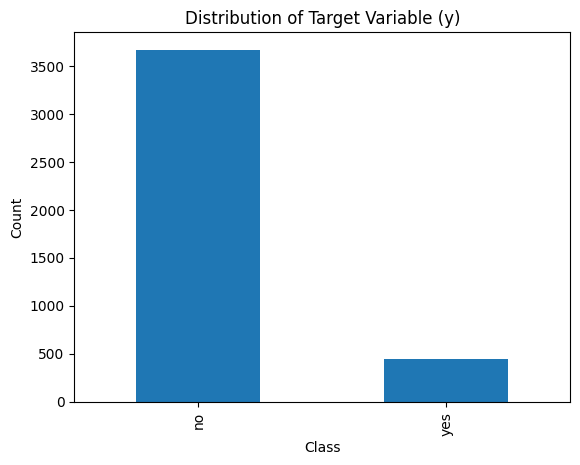

In [9]:
#Visualize distribution of target variable
df['y'].value_counts().plot(kind='bar')
plt.title("Distribution of Target Variable (y)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Numerical Variable Distributions

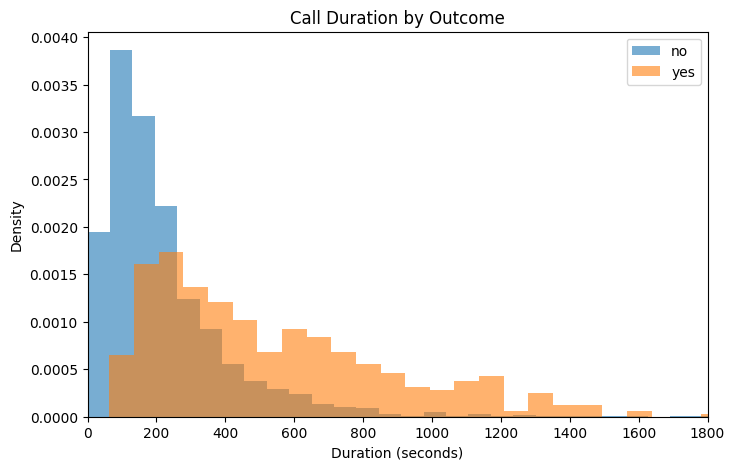

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df[df["y"] == "no"]["duration"],
         bins=50, alpha=0.6, label="no", density=True)

plt.hist(df[df["y"] == "yes"]["duration"],
         bins=50, alpha=0.6, label="yes", density=True)

plt.title("Call Duration by Outcome")
plt.xlabel("Duration (seconds)")
plt.ylabel("Density")
plt.legend()
plt.xlim(0, 1800)

plt.show()

Histogram comparing call duration for customers who subscribed vs. those who did not

Longer call durations are often associated with successful subscriptions, so we can expect to see a right-skewed distribution for the "yes" class and a more left-skewed distribution for the "no" class.

This feature shouldn't be included as the outcome is known after the call ends therefore including it in the model would cause data leakage.


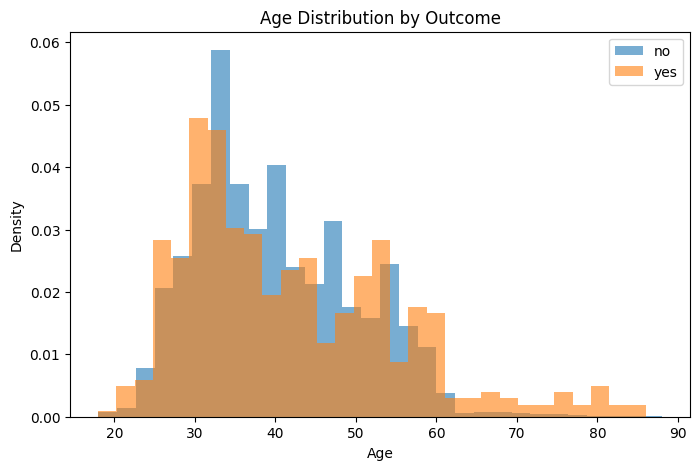

In [11]:
#Histogram comparing age distribution for customers who subscribed vs. those who did not
#Age can influence subscription likelihood, with certain age groups potentially more inclined to subscribe.
plt.figure(figsize=(8,5))

plt.hist(df[df["y"] == "no"]["age"],
         bins=30, alpha=0.6, label="no", density=True)

plt.hist(df[df["y"] == "yes"]["age"],
         bins=30, alpha=0.6, label="yes", density=True)

plt.title("Age Distribution by Outcome")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.show()

### Categorical Variable Distributions

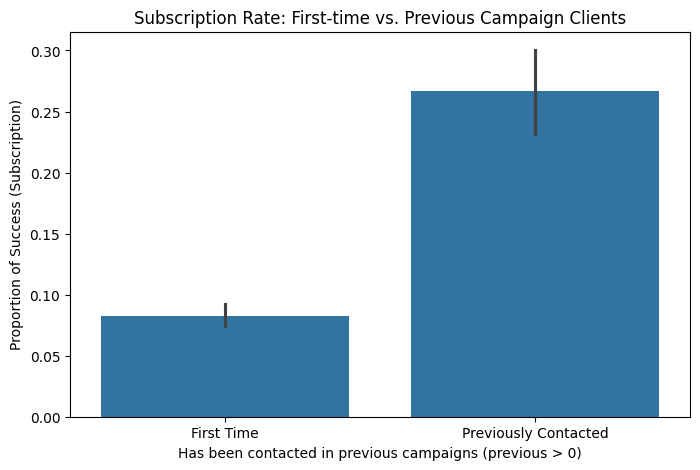

In [12]:
#Barplot comparing subscription rates for clients with and without previous campaign contacts
#Clients who have been contacted in previous campaigns may have a higher subscription rate due to increased familiarity with the bank's offerings, while first-time contacts may have a lower subscription rate.

df['y_numeric'] = df['y'].map({'yes': 1, 'no': 0})
df['has_previous'] = df['previous'] > 0

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='has_previous', y='y_numeric')

plt.title('Subscription Rate: First-time vs. Previous Campaign Clients')
plt.ylabel('Proportion of Success (Subscription)')
plt.xlabel('Has been contacted in previous campaigns (previous > 0)')
plt.xticks([0, 1], ['First Time', 'Previously Contacted'])
plt.show()

# Clean up the temporary column after plotting
df.drop(columns=['y_numeric', 'has_previous'], inplace=True)

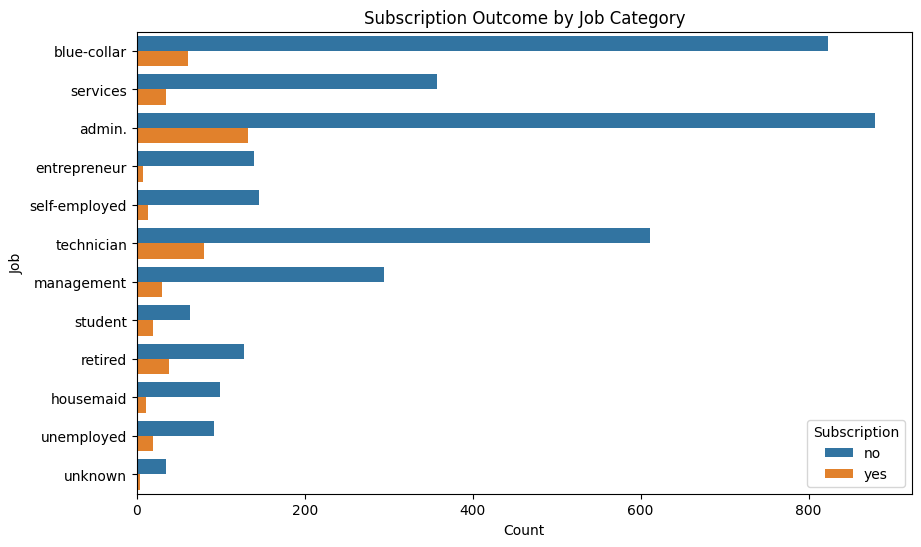

In [13]:
#Barplot comparing subscription rates across different job categories
#Certain job categories may have higher subscription rates due to factors like income stability, financial literacy, or lifestyle, which can influence their likelihood to subscribe to a term deposit.

plt.figure(figsize=(10,6))

sns.countplot(data=df, y='job', hue='y')

plt.title("Subscription Outcome by Job Category")
plt.xlabel("Count")
plt.ylabel("Job")
plt.legend(title="Subscription")
plt.show()

## Special Consideration Variables

One variable that needs special consideration is "duration". It is not available at prediction time and must be discarded from the feature set to avoid data leakage.

Another variable that needs special consideration is "pdays", 96.1% of rows have the value set as "999", meaning the customers have not been previously contacted before or the data has not been saved and is unknown. Instead of treating this variable as continuous it should be converted into a categorical variable of was previously contacted (similarly to "previous")

Finally we have to consider the variable "default", 19.5% of results have implicit missing values. very few clients will admit to being in default, therefore causing the variable to have near zero variance. This could be a potential variable to exclude from the feature set as well.


# Task 3: Task Ordering

## Pipeline and Justification

Task 1: Identifying the Prediction Target

Defines what we are predicting. We need to know what the target of our model is going to be. Every decision, feature, leakage and idea depends on knowing our target variable. No data is transformed, only understand what we are looking for. We ensure this so that we don't mistake the target with a feature.

Task 2: Data Loading and Exploration

Purely observational. No parameters are learned and no rows are modified. We need to understand our data, analyse what it contains and means. This must be task 2 so that we are informed on the data before making decisions about variables, features, encoding or scaling.

Task 3: Task Ordering

Although this isn't a direct task for the machine learning assignment i still believe that this is the right moment to do it.

Once the data is understood, the correct sequence can be justified and documented. Now we know enough about the data to justify each step. This will also help us plan out the project so we can do one step at a time.

Task 4: Data Splitting

This step has to be completed early so leakage is avoided in imputation, scaling and feature selection. The train/validation/test boundary must be established before any fitting transformation so that the validation and test sets are never seen by any fitted component (avoid leakage). Stratification on "y" is applied here to preserve the class distribution across all splits.

Task 5: Managing Missing Values

We need to decide what to do about the missing values before continuing. Imputation strategies need to be fitted on the training set and then applied to the validation and test sets. If done before splitting, test-set missingness patterns would influence the imputed values and training transformations, leaking distributional information.


Task 6: Encoding Categorical Variables

Encoding requires a clean representation, hence why it must be performed after managing the missing values so that "unknown" categories are resolved before the encoder is fitted. In addition encodes need to be fitted on the training set only to learn the vocabulary of categories. If the fitting is on the full dataset it would expose the encoder causing it to learn about categories in the validation and test data, leading to structural leakage. 

Task 7. Feature Selection

Variance thresholds and correlation analysis are computed on the training set only. They follow scaling so that all features are on comparable scales when computing correlations. "duration" is removed here on conceptual grounds (leakage risk and outcome being known after the result of duration). If feature selection were performed on the full dataset before splitting, retained features would be chosen with knowledge of validation/test variance and correlation structure.

Intially i placed this task after feature scaling, however after completing feature scaling i realised that by selecting features first, we can use the "Cutting the Long Tail" to remove features that provide insufficient signal in their raw or binary encoded state. This saves time as we might not have to scale certain features.

Task 8: Feature Scaling

Scalers are also fitted on the training set only to learn mean and standard deviation. They need to go after encoding so that all features are numeric. If fitted on the full dataset, the scaler would incorporate the mean and variance of validation/test rows, leaking global distribution statistics into the training normalisation. If done before it would affect the optimization of the logistic regression.

Task 9: Addressing Class Imbalance

Resampling is again applied only to the training set, after all preprocessing is complete. Resampling generates synthetic samples in the transformed feature space, so it must occur after encoding and scaling. This is also so that selected features are consisten between real and synthetic examples. Validation and test sets are never resampled, they must preserve the original class distribution to produce realistic evaluation metrics.

Task 10: Training a Logistic Regression Model 

All preprocessing is finalised. Feature space is defined, transoformations are fitted and class imabalance has been handled. The model is fitted on the (resampled) training set and evaluated on the untouched validation data. This order guarantees that evaluation metrics reflect genuine generalisation.

## Pipeline explanations

|  #  | Task | Allowed Information | Must not use | Data Leakage if unordered |
|-----|----------|----------|----------|----------|
|  1  |Identifying the Prediction Target|Full dataset (read-only) and business objectives          |  -        | -         |
|  2  |Data Loading and Exploration|Full dataset (read-only)          |  -        |    -      |
|  3  |Task Ordering|Observations from task 2          | Any transformations to the data         |     -     |
|  4  |Data Splitting|Full dataset + target distribution          |   No fitted parameters as well as specific feature values to determine the split|  Could lead to preprocessing leakage as the following steps will use future information in the training set        |
|  5  |Managing Missing Values|    Training set statistics      |    Values from the validation and test sets      |    Can lead to preprocessing leakage by incorporating holdout data into the imputation logic. Can lead to over optimistic performance estimates as you directly leak distributional data from the validation and test sets      |
|  6  |Encoding Categorical Variables|      Categories in the training set    |    Unique categories that only appear in the validation or test sets      |    Can lead to label leakage if the encoding uses target information. Model can also gain indirect knowledge of the holdout data meaning preporcessing leakage      |
|  7  |Feature Selection|    Training set only      |   Global statistics from the whole dataset       |  Selected features might be optimized for the whole dataset. Performance can become over optimistic.        |
|  8  |Feature Scaling|    Distributional statistics of the training set      |     Statistics of the full set     |    Scaling the training data using statistics from the test set contaminates the training process, leading to preprocessing leakage      |
|  9  |Addressing Class Imbalance|     Training set     |     Data from the validation and test sets     |  Resampling before splitting can cause synthetic samples to appear in both training and test sets, causing group leakage. This will also lead to overfitting        |
|  10 |Training a Logistic Regression Model|   Training set, features and targets      | Valdiation set labels  and test set       |   Using the validation set for training would cause leakage and end with an overfitted model       |

## Incorrect Ordering and Consequences

One example of incorrect ordering would be if you perform oversampling (SMOTE) on the entire dataset before splitting it into different parts. The algorithm would generate synthetic examples based on the whole population causing data leakage. When you split the data set later on very similar examples will appear in both the training and test sets. 

The model could achieve high precision, recall and accuracy because it recognizes the examples it saw during training. It would fail if it was shown unseen data as it has learned based on specific instances.

# Task 4: Data Splitting


## Split Proportions and Explanation

In [14]:
#Separating the features and target variable
x = df.drop(columns=["y"])
y = df["y"]

#Split the data into training and temp (which will be later split into val and test)
X_train, X_temp, y_train, y_temp = train_test_split(
    x, y,
    test_size=0.30,
    random_state=450,
    stratify=y
)

#Split the temp data into validation and test sets (50% each of the temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=450,
    stratify=y_temp
)

#Verify the split
print("Split summary")
print("=" * 52)
for name, y_split in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    total    = len(y_split)
    yes_n    = (y_split == "yes").sum()
    no_n     = (y_split == "no").sum()
    yes_pct  = yes_n / total * 100
    no_pct   = no_n  / total * 100
    print(f"\n{name} ({total:,} rows)")
    print(f"  no  : {no_n:>4}  ({no_pct:.1f}%)")
    print(f"  yes : {yes_n:>4}  ({yes_pct:.1f}%)")

Split summary

Train (2,883 rows)
  no  : 2567  (89.0%)
  yes :  316  (11.0%)

Validation (618 rows)
  no  :  551  (89.2%)
  yes :   67  (10.8%)

Test (618 rows)
  no  :  550  (89.0%)
  yes :   68  (11.0%)


The dataset is going to be split into three sets using 70% for training, and 15% for both validation and test sets.

Since we only have 4119 observations and approximately 10.9% of those are positive (451), by allocating 70% of the data to training we allow the model to observe enough examples (the minority are positive) to learn a decision boundary. The model has enough examples to know the pattern and generalize. 

The remaining 30% is split between the validation and test sets (15% each). This gives us enough examples to compute metrics such as precision and recall reliably.  Validation will be used during preprocessing and model tuning, whislt test set isn't used until the very end for a final report on the model. 

## Stratification for target variable

The target variable "y" is very imbalanced and with only 451 positive cases in the dataset a fully random split could produce a validation or test set have too many positive/negative cases hence losing the proportion that we have in the dataset. Stratified splitting will force each split to maintain the 89.1% : 10.9% ratio.

This ensures that the model trains on a minority class distribution and validation metrics are computed against a realisitc ratio. Results will also be reproducible and comparable each run.

## Pipeline splitting stage

The split has to be performed right after the exploration and task ordering, and before any fitting transformation (processing) is applied.

If it was performed later on the following types of leakage could occur:

Preprocessing Leakage: By calculating distributional statistics on the full dataset, future information is included in the model training data. The model will see the spread and range of the test set before it is evaluated.

Target leakage: If feature selection is performed before the split features might be selected because they correlate with targets in the validation or test sets.

Splitting later in the pipeline would cause information from the validation or test sets to be implicitly encoded into the transformations producing biased evaluation metrics and inflated performance results. The model will appear to work on the test set but when tested with real unseen data it will likely fail.

# Task 5: Managing Missing Values

## Explicit vs Implicit missing values

In [15]:
#Create a copy of datasets to avoid modifying the original dataframes
X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

print("Implicit missing values in training set")
print("=" * 50)

#Check for 'unknown' values in categorical columns and their relationship with the target variable
cat_cols = ["job", "marital", "education", "default", "housing", "loan"]
for col in cat_cols:
    n = (X_train[col] == "unknown").sum()
    pct = n / len(X_train) * 100
    sub_unk = y_train[X_train[col] == "unknown"].eq("yes").mean()
    sub_kno = y_train[X_train[col] != "unknown"].eq("yes").mean()
    print(f"  {col:<12} unknown={n:>3} ({pct:.1f}%)  "
          f"sub_rate_unknown={sub_unk:.3f}  sub_rate_known={sub_kno:.3f}")

#Check for '999' values in numerical columns and their relationship with the target variable
pdays_sentinel = (X_train["pdays"] == 999).sum()
print(f"\n  pdays==999: {pdays_sentinel} ({pdays_sentinel/len(X_train)*100:.1f}%) "
      f"- sentinel for 'never previously contacted'")

Implicit missing values in training set
  job          unknown= 31 (1.1%)  sub_rate_unknown=0.097  sub_rate_known=0.110
  marital      unknown=  8 (0.3%)  sub_rate_unknown=0.000  sub_rate_known=0.110
  education    unknown=124 (4.3%)  sub_rate_unknown=0.161  sub_rate_known=0.107
  default      unknown=545 (18.9%)  sub_rate_unknown=0.064  sub_rate_known=0.120
  housing      unknown= 73 (2.5%)  sub_rate_unknown=0.110  sub_rate_known=0.110
  loan         unknown= 73 (2.5%)  sub_rate_unknown=0.110  sub_rate_known=0.110

  pdays==999: 2782 (96.5%) - sentinel for 'never previously contacted'


### Summary

All of these results are based on the training set

Explicit: There are no explicit values in the dataset. 

Implicit: 

**Unknown Category**

| Column      | Unknown (train) | % of train | Subscription rate (unknown) | Subscription rate (known) | Strategy |
|-------------|----------------|------------|----------------------------|--------------------------| ---------- |
| "job"  | 31    | 1.1%    | 9.7%                    | 11.0%              |      Mode Imputation      |
| "marital" | 8     | 0.03%    | 0.0%                      | 11.0%                    |   Mode Imputation      |
| "education"   | 124     | 4.3%      | 16.1%                       | 10.7%                    |    Retain as category      |
| "default" | 545    | 18.9%   | 6.4%               | 12.0%     |     Retain as category    |
| "housing"   | 73      | 2.5%     | 11.0%                       | 11.0%                    |  Mode Imputation     |
| "loan"   | 73     | 2.5%      | 11.0%                      | 11.0%                    |   Mode Imputation   |


**999**

Sentinel value "999" in "pdays" is a numerical implicit missing value. "pdays" records the number of days since a client was last contacted in a previous campaign. The value "999" encodes "never previously contacted"  and is not a real measurement. It appears in 96.5% of training rows, making "pdays" effectively a near-binary variable rather than a continuous one. (Either they have been contacted or not)



## Strategy and Justification

### Code

In [16]:
#Impute 'unknown' with mode for job, marital, housing, loan
impute_cols = ["job", "marital", "housing", "loan"]
modes = {col: X_train[col].replace("unknown", pd.NA).mode()[0]
         for col in impute_cols}

print("\nMode imputation values (fitted on training set only):")
for col, val in modes.items():
    print(f"  {col:<10} → '{val}'")

for split in [X_train, X_val, X_test]:
    for col, mode_val in modes.items():
        split[col] = split[col].replace("unknown", mode_val)


Mode imputation values (fitted on training set only):
  job        → 'admin.'
  marital    → 'married'
  housing    → 'yes'
  loan       → 'no'


In [17]:
# No transformation needed, 'unknown' is kept as a valid level.
print("\n'default' and 'education': retaining 'unknown' as separate category.")
print(f"default unique values: {sorted(X_train['default'].unique())}")
print(f"education unique values: {sorted(X_train['education'].unique())}")


'default' and 'education': retaining 'unknown' as separate category.
default unique values: ['no', 'unknown', 'yes']
education unique values: ['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown']


In [18]:
#Split the variable into two new variables and drop the original "pdays"
for split in [X_train, X_val, X_test]:
    split["previously_contacted"] = (split["pdays"] != 999).astype(int)
    split["pdays_clean"] = split["pdays"].replace(999, 0)
    split.drop(columns=["pdays"], inplace=True)

# Verify the new features
print("\npdays engineering complete:")
print(f"previously_contacted - train: "
      f"{X_train['previously_contacted'].value_counts().to_dict()}")
print(f"pdays_clean - train non-zero: "
      f"{(X_train['pdays_clean'] > 0).sum()} rows")


pdays engineering complete:
previously_contacted - train: {0: 2782, 1: 101}
pdays_clean - train non-zero: 100 rows


In [19]:
#Verify if the code worked
cat_cols = ["job", "marital", "education", "default", "housing", "loan"]
for col in cat_cols:
    n = (X_train[col] == "unknown").sum()
    pct = n / len(X_train) * 100
    sub_unk = y_train[X_train[col] == "unknown"].eq("yes").mean()
    sub_kno = y_train[X_train[col] != "unknown"].eq("yes").mean()
    print(f"  {col:<12} unknown={n:>3} ({pct:.1f}%)  "
          f"sub_rate_unknown={sub_unk:.3f}  sub_rate_known={sub_kno:.3f}")

  job          unknown=  0 (0.0%)  sub_rate_unknown=nan  sub_rate_known=0.110
  marital      unknown=  0 (0.0%)  sub_rate_unknown=nan  sub_rate_known=0.110
  education    unknown=124 (4.3%)  sub_rate_unknown=0.161  sub_rate_known=0.107
  default      unknown=545 (18.9%)  sub_rate_unknown=0.064  sub_rate_known=0.120
  housing      unknown=  0 (0.0%)  sub_rate_unknown=nan  sub_rate_known=0.110
  loan         unknown=  0 (0.0%)  sub_rate_unknown=nan  sub_rate_known=0.110


### Strategy per variable

"job" - Mode Imputation (Data cleaning)

There are only 31 instances of this variable being unknown and the subscription rate of the unknown category is close enough to the known rate of 11% that the difference is unlikely to be meaningful at this sample size. I will carry out mode imputation using the training set and apply it across the validation and test sets.

"marital" - Mode Imputation (Data cleaning)

There are only 8 instances of this variable being unknown and the subscription rate of the unknown category is 0.0%. With so few observations this isn't statistically reliable and is more likely due to the sampling and splitting (chance). Keeping the separate category could provide unreliable results and destabalize the encoder. I will carry out mode imputation using the training set and apply it across the validation and test sets.

"education" - Retain as category (Modeling decision)

There are 124 unknown instances of this variable and the unknown subscription rate is 16.1% compared to the 10.7% of known. The clients that didn't discolse their education aren't a random part of the population, they belong in a different group. Being part of this unknown category has a higher subscription rate than the known category. 

Using mode imputation would misrepresent the 124 people who belong to a different group. Therefore we will retain "unknown" as a separate class for the model

"default" - Retain as category (Modeling decision)

There are 545 unknown instances (18.9% of total) of this variable and the unknown subscription rate is 6.4% compared to the known rate of 12.0%. This indicates that clients who decline to disclose their default status behave differently to those that do (lower subscription rate). 

Mode imputation would assing "no" to all these people and the signal would be lost, hence we are keeping the "unknown" category 

"housing" - Mode Imputation (Data cleaning)

There are 73 instances of this variable being unknown and the subscription rates for both unknown and unknown are the same, sitting at 11.0%. There is no evidence that the unknown category is carrying any predictive value. I will carry out mode imputation using the training set and apply it across the validation and test sets.

"loan" - Mode Imputation (Data cleaning)

There are 73 instances of this variable being unknown and the subscription rates for both unknown and unknown are the same, sitting at 11.0%. There is no evidence that the unknown category is carrying any predictive value. I will carry out mode imputation using the training set and apply it across the validation and test sets.

"pdays"

Since 96.5% of "pdays" values are the sentinel value "999" (extremely skewed), the column cannot be treated as a continuous variable. Passing it directly to a scaler would produce a heavily distorted normalisation dominated by a non-informative code. Two features are derived instead:

"previously_contacted":

Binary indicator: "1" if "pdays" != "999", else "0". 
Captures whether the client has any prior campaign history at all.

"pdays_clean": 

The actual number of days for clients who were previously contacted, set to "0" for all others. This preserves the recency signal for the 3.5% of clients with a actual prior contact.

The original "pdays" column is then dropped. This transformation is rule-based, no parameters are learned from data and is therefore applied identically to all splits without any risk of leakage. Keeping the column would cause multicollinearity between the new features and would distort scaling.

## Operations on missing variables

| Operation | Parameter learned | Leakage if fitted on full dataset |
|-----------|------------------|----------------------------------|
| Mode imputation ("job", "marital", "housing", "loan") | Mode value per column | Global mode absorbs val/test distribution; imputed values reflect unseen data |
| "unknown" category retention ("default", "education") | None | No leakage risk |
| "pdays" feature engineering | None| No leakage risk |

Only mode imputation requires a fitted parameter on the training set. All other operations in this task are deterministic transformations that are safe to apply uniformly across all splits.

## Data Cleaning vs Modeling decisions

The strategy for each variable is decided by considering the following: Does the fact that a value is missing carry predictive information in itself?

If it does, missingness should be preserved. If not, it is a structural gap that should be filled to avoid introducing sparse, uninformative categories into the model.

Data cleaning decisions:

Correct structural gaps where missingness is random and the unknown group behaves indistinguishably from the known population (it has no effect on the target variable), hence why we will perform mode imputation.

Modelling decisions:

Arise when the unknown group has a meaningfully different subscription rate, the missingness is has an effect on the outcome and should be preserved as its own category rather than collapsed into the majority class.

# Task 6: Encoding Categorical Variables

## Categorical variables, Types of Categorical values and justification

In [20]:
cat_cols = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
cat_cols

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

| Column        | Type    | Justification    |
|---------------|---------| -------- |
| "job"        | Nominal | Occupational categories with no meaningful numeric progression (just different types of jobs and sectors, no visible progression system)  |
| "marital"     | Nominal | No ordinal relationship, just a status. "married" is not greater than "single"    |
| "education"   |Ordinal | This variable has a clear progression in terms of qualification level. The natural ordering justifies ordinal encoding  |
| "default"     | Nominal | Binary flag     |
| "housing"     | Nominal | Binary flag      |
| "loan"        | Nominal | Binary flag    |
| "contact"     |  Nominal | Contact type, by cellular or cellphone, no numeric progression   |
| "month"      | Nominal | Although a cyclical pattern exists "may" is not greater than "june"   |
| "day_of_week" |  Nominal | Although a cyclical pattern exists "thursday" is not greater than "friday"   |
| "poutcome"    |  Nominal | Outcome of previous campaign with no numeric order (success or failure)   |

## Encoding Strategy

In [21]:
#Ordinal encoding for 'education' variable
#Define the order of education levels based on typical educational attainment hierarchy, with 'illiterate' being the lowest and 'university.degree' being the highest.
edu_order = [
    "illiterate", "basic.4y", "basic.6y", "basic.9y",
    "high.school", "professional.course", "university.degree"
]
#"unknown" maps to NaN
edu_map = {v: i for i, v in enumerate(edu_order)}  

#Add binary indicator before mapping (while string 'unknown' still exists)
for split in [X_train, X_val, X_test]:
    split["education_unknown"] = (split["education"] == "unknown").astype(int)

#Apply ordinal mapping; "unknown" becomes NaN
for split in [X_train, X_val, X_test]:
    split["education"] = split["education"].map(edu_map)

#Compute median on training set only, then impute all splits
edu_median = X_train["education"].median()
print(f"Education median (train): {edu_median} → '{edu_order[int(edu_median)]}'")

for split in [X_train, X_val, X_test]:
    split["education"] = split["education"].fillna(edu_median)

print("\nEducation ordinal mapping:")
for label, rank in edu_map.items():
    print(f"  {rank} → '{label}'")
print(f"  unknown → NaN → imputed as {edu_median}")

print(f"\neducation_unknown indicator (train): "
      f"{X_train['education_unknown'].value_counts().to_dict()}")

Education median (train): 4.0 → 'high.school'

Education ordinal mapping:
  0 → 'illiterate'
  1 → 'basic.4y'
  2 → 'basic.6y'
  3 → 'basic.9y'
  4 → 'high.school'
  5 → 'professional.course'
  6 → 'university.degree'
  unknown → NaN → imputed as 4.0

education_unknown indicator (train): {0: 2759, 1: 124}


**Ordinal Encoding - Manual Integer Mapping**

Applied to "education", by manually mapping education levels to a rank, we explicitly preserve the hierarchical signal, allowing the model to learn how different education levels could affect the target. Since we know and understand the different levels, we can maintin the order manually.


The ordinal mapping itself is rule-based and is therefore safe to apply across all splits without fitting, but the median used for imputing unknown values (discussed in the next section) is fitted on the training set only and constitutes a learned parameter.

**Handling "unknown" in "education"**

Initially i placed the "unknown" in the same ordinal encoder as the rest of the educations. After reflecting and rethinking i realised that this would be ranking unknown at the top level of education. Hence the following solution:

Rather than assigning "unknown" an arbitrary rank at the top or bottom of the scale (which would incorrectly imply it represents more or less education than the known categories), we treat it as genuinely missing and handle it in three steps:

*Indicator variable* ("education_unknown"): a binary flag set to "1" for rows where education was unknown. This preserves the predictive signal identified in Task 5, where unknown clients subscribed at 16.1% vs 10.7% for known clients.

*Map "unknown" -> "NaN"*: the ordinal mapping is applied only to the seven known categories, leaving unknown rows as "NaN".

*Median imputation*: the NaN values are filled with the training set median ("high.school", rank 4). The indicator variable carries the actual information about missingness, so the imputed value in the ordinal column is treated as neutral. 

The median is computed on the training set only to prevent leakage.

This approach is more principled than placing "unknown" at rank 7: it honestly represents uncertainty about education level while retaining the group's predictive signal through the indicator column.

In [22]:
#One-hot encoding for nominal variables
nominal_cols = [
    "job", "marital", "contact", "month",
    "day_of_week", "poutcome", "default", "housing", "loan"
]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
#Fitted on training set only to prevent data leakage and ensure consistent encoding across splits, even if some categories are missing in val/test sets.
ohe.fit(X_train[nominal_cols])

def apply_ohe(X, ohe, nominal_cols):
    ohe_array = ohe.transform(X[nominal_cols])
    ohe_df    = pd.DataFrame(
        ohe_array,
        columns=ohe.get_feature_names_out(nominal_cols),
        index=X.index
    )
    return pd.concat([X.drop(columns=nominal_cols), ohe_df], axis=1)

X_train_enc = apply_ohe(X_train, ohe, nominal_cols)
X_val_enc   = apply_ohe(X_val,   ohe, nominal_cols)
X_test_enc  = apply_ohe(X_test,  ohe, nominal_cols)

print(f"\nReference categories dropped (one per nominal variable):")
for col, cats in zip(nominal_cols, ohe.categories_):
    print(f"  {col:<15} → reference: '{cats[0]}'")


Reference categories dropped (one per nominal variable):
  job             → reference: 'admin.'
  marital         → reference: 'divorced'
  contact         → reference: 'cellular'
  month           → reference: 'apr'
  day_of_week     → reference: 'fri'
  poutcome        → reference: 'failure'
  default         → reference: 'no'
  housing         → reference: 'no'
  loan            → reference: 'no'


**One-Hot Encoding**

Applied to all 9 nominal columns. Dropping the first category per variable removes the dummy variable trap (Multicollinearity, coefficients would be unstable, redundant and non-identifiable). Without dropping one level, the resulting binary columns are perfectly linearly dependent (one column can always be reconstructed from the others, they all add up to 1).

Applying OHE instead of ordinal encoding prevents the model from assuming a false numerical ranking between unordered categories.

The encoder is fitted on the training set only. This ensures that the vocabulary of categories (which values exist and which is dropped as the reference) is learned exclusively from training data. Fitting on the full dataset would expose the encoder to categories from the validation and test sets, constituting distribution and preprocessing leakage.

## Encoding Changes

### Dimensionality of dataset

In [23]:
print(f"\nDimensionality change:")
print(f"  After Task 5 (pre-encoding)          : {X_train.shape[1] - 1} columns")
print(f"  After education_unknown indicator    : {X_train.shape[1]} columns")
print(f"  After full encoding (ordinal + OHE)  : {X_train_enc.shape[1]} columns")


Dimensionality change:
  After Task 5 (pre-encoding)          : 21 columns
  After education_unknown indicator    : 22 columns
  After full encoding (ordinal + OHE)  : 45 columns


Encoding (One-Hot Encoder) will increase the dimensionality significantly. High cardinality features such as "job" or "month" will increase the feature space.

Dimensionality has increased from 21 columns to 45 columns.

This increase in dimensionality can also be a risk. Data points will be more spread out, there is increased variance risk and overfitting risk as there are more features. Regularization will be important.

### Interpretability of model coefficients

In Logistic Regression, encoding changes how we read the weights. 

OHE: Each dummy coefficient represents the log-odds of subscription relative to the category dropped (the baseline) holding all other features constant. This makes coefficients directly interpretable as pairwise category comparisons.

Ordinal: A single coefficient represents the effect of moving up one level in the hierarchy. A positive coefficient 
indicates that higher education is associated with increased subscription probability.

The "education_unknown" coefficient independently captures the effect of belonging to the 
unknown group, cleanly separated from the education rank signal.

### Types of decision boundaries

Logistic Regression is limited to a linear decision boundary in feature space. Before encoding, the raw categorical strings are not in any vector space, the model can't use them. 

Encoding is the primary way we add expressiveness. By splitting a single categorical variable into multiple binary features, we allow the linear model to effectively learn "if-then" logic (for example: if "job" is "student", then subscription is more likely) that would be impossible to capture in a single raw text column. 

The model in essence assings a separate weight to each category relative to its reference. This pushes the complexity into the features rather than the model architecture itself.


# Task 7: Feature Selection

 Discuss the consequences of performing feature selection on the entire dataset before splitting.

Note: Feature selection is not purely statistical. Your reasoning should explicitly connect your decisions to the
assumptions and stability of Logistic Regression.

Feature selection should performed after encoding and before scaling. By using this ordering variance and correlation are assessed on the natural, unscaled values of each feature. Performing feature selection after "StandardScaler" would be methodologically problematic for variance — the scaler forces all continuous column variances to exactly 1.0 by construction, making a variance threshold meaningless for those columns. Pearson correlations are scale-invariant and would be numerically identical either way, but consistency with the natural data scale makes the analysis more interpretable.

## Why must feature selection be performed using training set only?

Variance thresholds and correlation coefficients are statistics learned directly from data. If it was computed on the whole dataset, the selection would be informed by the variance and correlations of the validation and test sets (preprocessing and distributional leakage), choice features in training would be influenced. This produces overly optimistic evaluations and doesn't reflect real results with unseen data.

## Low Variance Features

In [24]:
#Identify binary and continuous columns for variance analysis
binary_cols     = [c for c in X_train_enc.columns if X_train_enc[c].nunique() == 2]
continuous_cols = [c for c in X_train_enc.columns if X_train_enc[c].nunique() > 2]

#Set variance threshhold to 0.01
VAR_THRESHOLD = 0.01

#Calculate variance for binary features and identify low-variance features
binary_variances = X_train_enc[binary_cols].var().sort_values()
low_var_cols = binary_variances[binary_variances < VAR_THRESHOLD].index.tolist()

#Report low-variance binary features and their variances, along with counts for the most extreme cases
print(f"Low variance binary features (threshold = {VAR_THRESHOLD}):")
for col in low_var_cols:
    print(f"  {col:<20} variance = {binary_variances[col]:.6f}")

print(f"\n  default_yes : {int(X_train_enc['default_yes'].sum())} positive case(s) "
      f"in {len(X_train_enc)} training rows → removed")
print(f"month_dec: {int(X_train_enc['month_dec'].sum())} rows "
      f"→ retained")

Low variance binary features (threshold = 0.01):
  default_yes          variance = 0.000347
  month_dec            variance = 0.005521

  default_yes : 1 positive case(s) in 2883 training rows → removed
month_dec: 16 rows → retained


The variance threshold is applied to binary and OHE columns only. Continuous columns are excluded since  their variance reflects measurement scale and units rather than informativeness, and comparing raw variances across features like "nr.employed" with a range of approximately 265  and "age" with range approximately 70 is not meaningful without standardisation. Continuous features are also excluded because none of them exhibit near-zero variance.

A threshold of 0.01 is used, corresponding to a feature where one class appears in fewer than ~1% of rows (99% of values are the same). Such a feature is effectively near-constant and provides almost no discriminative signal. A coefficient fitted on it would be numerically unstable: tiny changes in the training sample could flip its sign, making it unreliable.

| Feature       | Variance  | Minority count (train) | Decision   |
|---------------|-----------|------------------------|------------|
| "default_yes" | 0.000347  | 1 positive case        | Remove |
| "month_dec"   | 0.005521  | 16 rows                | Retain |

"default_yes" is removed, it only has 1 positive case in 2,883 training rows, this column is functionally constant. No model can learn a reliable coefficient from a single observation, and the feature contributes nothing but numerical noise.

"month_dec" is borderline (variance = 0.006) but i decided to retain it. Although it is sparse, December 
contacts may carry genuine seasonal signal. L2 regularisation in Logistic Regression will naturally shrink its coefficient toward zero if it proves uninformative.

## Highly correlated features

In [25]:
CORR_THRESHOLD = 0.85

corr_matrix = X_train_enc[continuous_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = upper.stack()[upper.stack() > CORR_THRESHOLD].sort_values(ascending=False)

print(f"\nHighly correlated pairs (threshold = {CORR_THRESHOLD}):")
for (col1, col2), val in high_corr_pairs.items():
    print(f"  {col1} ↔ {col2}: r = {val:.3f}")

print(f"\nCorrelation matrix:")
macro = ["emp.var.rate", "euribor3m", "nr.employed", "cons.price.idx"]
print(X_train_enc[macro].corr().round(3).to_string())


Highly correlated pairs (threshold = 0.85):
  emp.var.rate ↔ euribor3m: r = 0.970
  euribor3m ↔ nr.employed: r = 0.943
  emp.var.rate ↔ nr.employed: r = 0.898

Correlation matrix:
                emp.var.rate  euribor3m  nr.employed  cons.price.idx
emp.var.rate           1.000      0.970        0.898           0.760
euribor3m              0.970      1.000        0.943           0.662
nr.employed            0.898      0.943        1.000           0.481
cons.price.idx         0.760      0.662        0.481           1.000


Correlation analysis is applied to the continuous columns only, computed on the training set. OHE binary columns are excluded (already considered in low variance selection), as Pearson correlation between binary columns does not carry the same multicollinearity implications as between continuous features, and removing OHE dummies on correlation grounds would discard legitimate category level information.

I will use a correlation threshold of 0.85 which is a widely accepted value. Correlations above this level indicate near-linear dependencies between features, which cause multicollinearity in Logistic Regression. In its presence, coefficient estimates become highly sensitive to small perturbations in the training data, meaning the model cannot reliably attribute shared variance to one feature vs another. This produces unstable coefficients with potentially misleading signs. L2 regularisation partially mitigates this but does not eliminate it.

The three pairs exceeding the threshold are the following:

| Pair                              | Correlation |
|-----------------------------------|-------------|
| "emp.var.rate" ↔ "euribor3m"     | 0.970       |
| "euribor3m" ↔ "nr.employed"   | 0.943       |
| "emp.var.rate" ↔ "nr.employed"   | 0.898       |

Full correlation matrix:

|                  | "emp.var.rate" | "euribor3m" | "nr.employed" | "cons.price.idx" |
|------------------|---------------|-------------|---------------|-----------------|
| "emp.var.rate"   | 1.000         | 0.970       | 0.898         | 0.760           |
| "euribor3m"      | 0.970         | 1.000       | 0.943         | 0.662           |
| "nr.employed"    | 0.898         | 0.943       | 1.000         | 0.481           |
| "cons.price.idx" | 0.760         | 0.662       | 0.481         | 1.000           |

Retaining all three variables provides the model with three near-identical signals, producing unstable and uninterpretable coefficient estimates across the cluster.

Due to this, "euribor3m" and "nr.employed" will be removed whilst "emp.var.rate" is retained. We keep "emp.var.rate" is because directly measures employment variation rate rather than level indicators, making it the most informative summary compared to the others. "cons.price.idx" (r = 0.760 with "emp.var.rate") falls below the 0.85 threshold and is retained.

## Features that should be removed based on conceptual considerations

"duration" records the length of the phone call in seconds. It is strongly associated with subscription, clients who subscribe tend to have longer calls however it is unavailable at prediction time. The purpose of this model is to predict 
subscription before or at the moment of contact. Call duration is only known after the call ends, at which point the outcome is already known. Therefore "duration" should be removed as a feature

Including "duration" constitutes temporal leakage, it encodes information that is a direct consequence of the outcome rather than a cause of it. A model trained with "duration" would appear to perform extremely well in evaluation but would be completely unusable in deployment.

## Removing Features

In [26]:
#Based on the variance and correlation analysis (as well as conceptual understanding), we will drop the following features:
drop_cols = ["default_yes", "duration", "euribor3m", "nr.employed"]

print(f"\nFeatures removed ({len(drop_cols)}):")
print(f"default_yes - near-zero variance (1 positive case in train)")
print(f"duration - target leakage (not available at prediction time)")
print(f"euribor3m - r = 0.970 with emp.var.rate")
print(f"nr.employed - r = 0.898 with emp.var.rate, r = 0.943 with euribor3m")

X_train_sel = X_train_enc.drop(columns=drop_cols)
X_val_sel   = X_val_enc.drop(columns=drop_cols)
X_test_sel  = X_test_enc.drop(columns=drop_cols)



Features removed (4):
default_yes - near-zero variance (1 positive case in train)
duration - target leakage (not available at prediction time)
euribor3m - r = 0.970 with emp.var.rate
nr.employed - r = 0.898 with emp.var.rate, r = 0.943 with euribor3m


## Consequences of performing on the entire dataset

If feature selection is performed on the entire dataset before splitting this would cause over optimistic results. The problem will produces inflated performance metrics on the validation and test sets.

You will believe you have the most significant features and predictors, however the correlations might only exist due to distributional leaking

When deployed on truly unseen data, the model will likely fail  because it never learned to generalize. It only learned to recognize patterns that it was informed about during the biased selection phase (preprocessing leakage).

# Task 8: Feature Scaling

## Identify numerical features that require scaling

In [27]:
#Identify binary and continuous columns for scaling decisions
binary_cols     = [c for c in X_train_sel.columns if X_train_sel[c].nunique() == 2]
continuous_cols = [c for c in X_train_sel.columns if X_train_sel[c].nunique() > 2]

print(f"Binary/indicator columns ({len(binary_cols)}) — not scaled:")
print(f"  {binary_cols}\n")
print(f"Continuous columns ({len(continuous_cols)}) — will be scaled:")
print(f"  {continuous_cols}")

Binary/indicator columns (33) — not scaled:
  ['previously_contacted', 'education_unknown', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success', 'default_unknown', 'housing_yes', 'loan_yes']

Continuous columns (8) — will be scaled:
  ['age', 'education', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'pdays_clean']


In [28]:
#Code for computing summary statistics and outlier counts for continuous columns in the training set before scaling
stats = X_train_sel[continuous_cols].describe().T[["mean", "std", "min", "max"]]
stats["range"] = stats["max"] - stats["min"]
stats["skew"]  = X_train_sel[continuous_cols].skew()

# Outlier count per column using IQR method
outlier_counts = {}
for c in continuous_cols:
    q1, q3 = X_train_sel[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = ((X_train_sel[c] < q1 - 1.5 * iqr) |
                (X_train_sel[c] > q3 + 1.5 * iqr)).sum()
    outlier_counts[c] = outliers

stats["outliers"] = pd.Series(outlier_counts)
print("Continuous column statistics (training set, pre-scaling):")
print(stats.round(3).to_string())

Continuous column statistics (training set, pre-scaling):
                  mean     std     min     max   range   skew  outliers
age             40.279  10.364  18.000  88.000  70.000  0.693        27
education        4.181   1.609   0.000   6.000   6.000 -0.535         0
campaign         2.545   2.578   1.000  29.000  28.000  3.783       165
previous         0.185   0.543   0.000   6.000   6.000  4.238       401
emp.var.rate     0.076   1.573  -3.400   1.400   4.800 -0.736         0
cons.price.idx  93.577   0.584  92.201  94.767   2.566 -0.211         0
cons.conf.idx  -40.443   4.626 -50.800 -26.900  23.900  0.312        36
pdays_clean      0.195   1.226   0.000  21.000  21.000  8.598       100


After encoding, the dataset contains 45 columns however after feature selection there are now 41. These fall into two categories:

Binary columns (33 total), no scaling:
All OHE dummies, "previously_contacted", and "education_unknown" are already binary columns (0 or 1). Scaling these would distort their binary meaning and make them harder to interpret. A StandardScaler applied to a column with values in (0 or 1) would produce negative values, which is meaningless for an indicator variable.

Continuous columns (8 total), need scaling:

| Column           | Mean      | Std     | Min      | Max      | Range    | Skew   | Outliers |
|------------------|-----------|---------|----------|----------|----------|--------|----------|
| "age"            | 40.28     | 10.36   | 18.0     | 88.0     | 70.0     | 0.69   | 27       |
| "education"     | 4.18      | 1.61    | 0.0      | 6.0      | 6.0      | −0.54  | 0        |
| "campaign"        | 2.55      | 2.58    | 1.0      | 29.0     | 28.0     | 3.78   | 165      |
| "previous"       | 0.19      | 0.54    | 0.0      | 6.0      | 6.0      | 4.24   | 401      |
| "emp.var.rate"    | 0.08      | 1.57    | −3.4     | 1.4      | 4.8      | −0.74  | 0        |
| "cons.price.idx" | 93.58     | 0.58    | 92.2     | 94.8     | 2.6      | −0.21  | 0        |
| "cons.conf.idx"   | −40.44    | 4.63    | −50.8    | −26.9    | 23.9     | 0.31   | 36       |
| "pdays_clean"   | 0.20      | 1.23    | 0.0      | 21.0     | 21.0     | 8.60   | 100      |

The ranges vary enormously, "age" spans around 70 units while "cons.price.idx" spans only  2.6. Without scaling, Logistic Regression would assign disproportionate weight to features with large absolute values simply because of their scale (bigger number), not their predictive power.

## Scaling Strategy and Justification

In [29]:
#Standard scaling for continuous features, fitted only on the training set to prevent data leakage and ensure that scaling parameters are derived solely from the training data distribution.
scaler = StandardScaler()
scaler.fit(X_train_sel[continuous_cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [30]:
#Function to apply the fitted scaler to a given dataset, ensuring that only the continuous columns are transformed while binary/indicator columns remain unchanged.
def apply_scaler(X, scaler, continuous_cols):
    X = X.copy()
    X[continuous_cols] = scaler.transform(X[continuous_cols])
    return X

X_train_scaled = apply_scaler(X_train_sel, scaler, continuous_cols)
X_val_scaled   = apply_scaler(X_val_sel,   scaler, continuous_cols)
X_test_scaled  = apply_scaler(X_test_sel,  scaler, continuous_cols)

In [31]:
#Print scaling parameters and post-scaling stats to verify that continuous features have been standardized to mean ~0 and std ~1, while shapes and NaN counts remain consistent across splits.
print("\nScaler parameters (fitted on training set only):")
print(f"{'Column':<20} {'Mean':>10} {'Std':>10}")
print(f"{'-'*42}")
for col, mean, std in zip(continuous_cols, scaler.mean_, scaler.scale_):
    print(f"  {col:<20} {mean:>10.3f} {std:>10.3f}")

print("\nPost scaling stats for continuous cols (train) - should be ~mean=0, std=1:")
scaled_stats = X_train_scaled[continuous_cols].agg(["mean", "std"]).T
scaled_stats.columns = ["mean", "std"]
print(scaled_stats.round(6).to_string())

print(f"\nShapes unchanged - Train: {X_train_scaled.shape} | "
      f"Val: {X_val_scaled.shape} | Test: {X_test_scaled.shape}")

print(f"\nNaN check - Train: {X_train_scaled.isna().sum().sum()} | "
      f"Val: {X_val_scaled.isna().sum().sum()} | "
      f"Test: {X_test_scaled.isna().sum().sum()}  ✓")


Scaler parameters (fitted on training set only):
Column                     Mean        Std
------------------------------------------
  age                      40.279     10.362
  education                 4.181      1.608
  campaign                  2.545      2.578
  previous                  0.185      0.543
  emp.var.rate              0.076      1.573
  cons.price.idx           93.577      0.584
  cons.conf.idx           -40.443      4.625
  pdays_clean               0.195      1.226

Post scaling stats for continuous cols (train) - should be ~mean=0, std=1:
                mean       std
age              0.0  1.000173
education       -0.0  1.000173
campaign        -0.0  1.000173
previous         0.0  1.000173
emp.var.rate     0.0  1.000173
cons.price.idx  -0.0  1.000173
cons.conf.idx   -0.0  1.000173
pdays_clean     -0.0  1.000173

Shapes unchanged - Train: (2883, 41) | Val: (618, 41) | Test: (618, 41)

NaN check - Train: 0 | Val: 0 | Test: 0  ✓


I will apply Standardization which will transofrm each feature to have a 0 mean and unit variance of 1. 

Standardization is robust to outliers, other alternatives such as min-max normalisation would squeeze the data into a small range if extreme outliers exist (highly sensitive to outliers). Standardization is more resilient as it uses mean and standard deviation rather than range extremes. As we observed a highn amount of columns having high skews and outliers standardization is the optimal scaling strategy.

Another reason is because many optimization algorithms assume features are centered around 0 with similar (average) spreads. It also allows for comparison between different features that have very different raw data units (for example comparing "age" and "previous").

## Fitting Transformations

Fit on Training Set Only

The StandardScaler must be fitted on the training set only, learning $\mu_{\text{train}}$ and $\sigma_{\text{train}}$ exclusively from training rows. These same parameters are then used to transform the validation and test sets.

If the scaler were fitted on the full dataset, $\mu$ and $\sigma$ would incorporate the mean and variance of validation and test rows, leaking their distributional properties into the normalisation applied during training (preprocessing leakage). The model would be trained on features that have been partially normalised using information it should not have access to, producing optimistically biased evaluation metrics.

## How does feature scaling affect gradient based optimization

Logistic Regression uses optimization solvers (like gradient descent or liblinear) that are highly sensitive to feature scales.

Without scaling, features with large numerical magnitudes (like "age") produce much larger gradient updates than smaller features (like "previous")

Scaling prevents these large features from dominating the learning signal, leading to faster convergence and more stable training.

## How does feature scaling affect magnitude and comparability of model coefficients

Scaling is really important when interpreting model's weights and the comparability of model coefficients. Without scaling the magnitude of a coefficient is directly linked to the feature's raw units, it doesn't necessarily mean a feature is important if there is a large coefficient. After standardization  all coefficients are expressed in units of standard deviation, which allows us to directly compare them. We will now be able to compare features fairly by comparing absolute values for coefficients.

Scaling is also important as large magnitude features (before scaling) cause  massive gradient updates that influence learning leading to slower or unstable convergence.

## How does feature scaling affect the interpretation of regularization penalties

In logistic regression, regularization (L1 or L2) adds a penalty term, (λΩ(θ)) to the objective function to discourage large coefficients and prevent overfitting. Features with small raw values are forced to have large coefficients to compensate for their small values and are therefore heavily penalized. (for large raw values they need small coefficients and are lightly penalized) After standardization the regularization penalty is applied fairly and uniformly across all features allowing the model to shrink coefficients based on actual predictive importance.

# Task 9: Addressing Class Imbalance

## Class Distribution in the Training Set

In [32]:
print("Class distribution across splits")
print("=" * 52)
for name, y_split in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    no = (y_split == "no").sum()
    yes = (y_split == "yes").sum()
    total = len(y_split)
    print(f"\n{name} ({total:,} rows)")
    print(f"no  : {no:>4}  ({100*no/total:.1f}%)")
    print(f"yes : {yes:>4}  ({100*yes/total:.1f}%)")
    print(f"ratio: {no/yes:.1f}:1")

zero_rule_acc = (y_val == "no").mean()
print(f"\nZero Rule baseline (always predict 'no') - val accuracy: "
      f"{zero_rule_acc*100:.1f}%")
print("High accuracy is trivially achievable; accuracy alone is a misleading metric.")

Class distribution across splits

Train (2,883 rows)
no  : 2567  (89.0%)
yes :  316  (11.0%)
ratio: 8.1:1

Validation (618 rows)
no  :  551  (89.2%)
yes :   67  (10.8%)
ratio: 8.2:1

Test (618 rows)
no  :  550  (89.0%)
yes :   68  (11.0%)
ratio: 8.1:1

Zero Rule baseline (always predict 'no') - val accuracy: 89.2%
High accuracy is trivially achievable; accuracy alone is a misleading metric.


| Split      | "no"              | "yes"            | Ratio  |
|------------|-------------------|------------------|--------|
| Train      | 2,567 (89.0%)     | 316 (11.0%)      | 8.1:1  |
| Validation | 551 (89.2%)       | 67 (10.8%)       | 8.2:1  |
| Test       | 550 (89.0%)       | 68 (11.0%)       | 8.1:1  |

The training set has an 8.1:1 class imbalance. This is a significant concern for this prediction task for two reasons:

Model bias: Logistic Regression minimises the overall loss. With 89% of rows belonging to the negative class, the optimization  is dominated by the majority class, which can lead to poor recall for the minority class. The Zero Rule baseline (always predict "no") achieves 89.2% accuracy on the validation set, illustrating that high accuracy is trivially achievable and therefore a misleading metric here.

This often results in low recall for the minority class, meaning many true subscribers may be misclassified as non-subscribers.

This imbalance is a concern since standard logistic regression assigns equal penalty per misclassified observation, not per class. If the model predicts "no" for every instance it will appear to have high accuracy, however since the primary goal of the model is to identify and predict subscribers the model wouldn't be practical.

## Resampling Strategy, pipeline order and assumptions + effects

In [33]:
#Create binary versions of the target variable for modeling purposes, where 'yes' is encoded as 1 and 'no' as 0.
y_train_bin = (y_train == "yes").astype(int)
y_val_bin   = (y_val   == "yes").astype(int)
y_test_bin  = (y_test  == "yes").astype(int)

In [34]:
#Apply SMOTE to the training data to address class imbalance by generating synthetic samples of the minority class ("yes")
smote = SMOTE(random_state=450)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train_bin)

In [35]:
#Print summary of the resampling process, showing the change in class distribution in the training set after applying SMOTE, while confirming that the validation and test sets remain unchanged with their original distributions.
print(f"\nResampling summary (SMOTE)")
print("=" * 52)
print(f"Before - rows: {X_train_scaled.shape[0]:,}  |  "
      f"no: {(y_train_bin==0).sum()}  yes: {(y_train_bin==1).sum()}  "
      f"ratio: {(y_train_bin==0).sum()/(y_train_bin==1).sum():.1f}:1")
print(f"After - rows: {X_train_res.shape[0]:,}  |  "
      f"no: {(y_train_res==0).sum()}  yes: {(y_train_res==1).sum()}  "
      f"ratio: {(y_train_res==0).sum()/(y_train_res==1).sum():.1f}:1")
print(f"Synthetic minority samples added: "
      f"{X_train_res.shape[0] - X_train_scaled.shape[0]:,}")

print(f"\nVal and test sets unchanged (original distribution preserved):")
print(f"Val  - no: {(y_val_bin==0).sum()}  yes: {(y_val_bin==1).sum()}  "
      f"ratio: {(y_val_bin==0).sum()/(y_val_bin==1).sum():.1f}:1")
print(f"Test - no: {(y_test_bin==0).sum()}  yes: {(y_test_bin==1).sum()}  "
      f"ratio: {(y_test_bin==0).sum()/(y_test_bin==1).sum():.1f}:1")

print(f"\nX_train_res shape: {X_train_res.shape}")
print(f"NaN check: {np.isnan(X_train_res).sum()}")


Resampling summary (SMOTE)
Before - rows: 2,883  |  no: 2567  yes: 316  ratio: 8.1:1
After - rows: 5,134  |  no: 2567  yes: 2567  ratio: 1.0:1
Synthetic minority samples added: 2,251

Val and test sets unchanged (original distribution preserved):
Val  - no: 551  yes: 67  ratio: 8.2:1
Test - no: 550  yes: 68  ratio: 8.1:1

X_train_res shape: (5134, 41)
NaN check: age                     0
education               0
campaign                0
previous                0
emp.var.rate            0
cons.price.idx          0
cons.conf.idx           0
previously_contacted    0
pdays_clean             0
education_unknown       0
job_blue-collar         0
job_entrepreneur        0
job_housemaid           0
job_management          0
job_retired             0
job_self-employed       0
job_services            0
job_student             0
job_technician          0
job_unemployed          0
marital_married         0
marital_single          0
contact_telephone       0
month_aug               0
month_dec 

Resampling Strategy: SMOTE

SMOTE is applied to the training set to address the imbalance as it generates synthetic minority class examples. It achieves this by interpolating between real and existing minority instances and their k-neartest neighbours rather than simply duplicating them.

SMOTE assumes that interpolating between neighbouring minority instances will produce valid new observations. After SMOTE the training set will become balanced (1:1 ratio), which gives the model exposre to both classes during optimization.

This will increase the minority class region in the feature space, forcing the logistic regression solver to learn a linear decision boundary that cosniders the minority class distribution.

SMOTE generates synthetic samples by interpolating in the encoded, scaled feature space. Applying it before encoding and scaling would interpolate between raw strings and data, generating synthetic points at the wrong scale distorting the real meaning. Both would produce meaningless synthetic observations.

The validation and test sets must never be resampled since they will preserve the original class distribution to ensure that the model will be tested on realistic data (with the correct distribution). Resampling both of these data sets as well would not represent real unseen data.

**Where in the pipeline resampling must occur?**

SMOTE is applied after all preprocessing is complete (missing value handling, encoding, feature selection and feature scaling). It should be applied to the training set only.

### Why was SMOTE chosen over other alternatives

Random oversampling duplicates existing minority rows exactly, which can cause the model to memorise specific training examples rather than learn the underlying distribution. SMOTE's interpolation produces new synthetic points that generalise the minority class boundary more effectively.

Random undersampling discards majority-class rows, which risks losing genuine information and signal from the 2,567 "no" observations. With only 316 minority examples, undersampling would reduce the training set to ~632 rows — far too few for a stable and reliable model.

ADASYN is an adaptive variant of SMOTE that generates more synthetic samples in regions where the classifier is weakest. Although this option could be a valid alternative it is going to add more complexity and there isn't a clear benifit for the class boundary we expect from logisitic regression.

## What Would Happen if Resampling Were Applied Before Splitting

If we were to apply ressampling before splitting the data set we would introduce data leakage and corrupted/unstable/unreliable distributions. 

If we apply SMOTE before splitting, synthetic points could be generated based from validation or test data and this could end up in the training set. The model would be trained on synthetic data points from the evaluation data causing inflated optimistic results.

In addition validation and test sets would contain synthetic rows, they would no longer reflec the true real world distribution. Precision, recall and F1 would have little meaning since the model would generalise against a fake distribution rather than the real world imbalance that we can observe.

## How does class imbalance affect evaluation metrics such as accuracy, precision, and recall

**Accuracy**

This metric will become misleading as the Zero Rule baseline that  always predicts "no" would achieve 89.2% accuracy. Accuracy rewards majority-class predictions and doesn't indicate much about the performance of the minority class.

**Precision**

This measures the fraction of clients predicted as subscribers and actually subscribe ($\frac{TP}{TP + FP}$). A model that rarely predits "yes" can achieve high precision but miss most subscribers (low recall). High precision ensures the bank doesn't waste resources on clients that are unlikely to subscribe. Imbalance often reduces precision if the model over predicts minority class.

**Recall**

This measures the proportion of actual subscribers the model succesfuly identified ($\frac{TP}{TP + FN}$). Under imbalance a model biased towards "no" will have very low recall and theminority class is systematically missed. 

For this model recall is very important as missing a true subscriber loses the bank money whereas a false positive will just be an extra call.

**AUC-ROC**

This is often the preferred metric for imbalanced tasks as it evaluates the tradeoff between the true positive rate and false positive rate across all decision thresholds.

**F1 score**

This is more inforamtive than accuracy under imbalance since it penalises models that sacrifice precision or recall.

# Task 10:  Training a Logistic Regression Model

## Model Training Code

In [36]:
#Train Logistic Regression on resampled training set
#"max_iter=1000" is set to ensure convergence given the 41-feature encoded space.
lr = LogisticRegression(max_iter=1000, random_state=450)
lr.fit(X_train_res, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",450
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [37]:
#Generate predictions on validation set
y_pred = lr.predict(X_val_scaled)
y_prob = lr.predict_proba(X_val_scaled)[:, 1]

In [38]:
#Compute metrics
acc = accuracy_score(y_val_bin, y_pred)
prec = precision_score(y_val_bin, y_pred)
rec = recall_score(y_val_bin, y_pred)
f1 = f1_score(y_val_bin, y_pred)
zero_rule = (y_val_bin == 0).mean()
cm = confusion_matrix(y_val_bin, y_pred)

print("Validation Set Results")
print("=" * 40)
print(f"Accuracy: {acc:.3f}")
print(f"Zero Rule: {zero_rule:.3f} - (baseline)")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"\nConfusion Matrix:")
print(f"TN={cm[0,0]}  FP={cm[0,1]}")
print(f"FN={cm[1,0]}  TP={cm[1,1]}")
print(f"\nClassification Report:")
print(classification_report(y_val_bin, y_pred, target_names=["no", "yes"]))

Validation Set Results
Accuracy: 0.783
Zero Rule: 0.892 - (baseline)
Precision: 0.287
Recall: 0.672
F1 Score: 0.402

Confusion Matrix:
TN=439  FP=112
FN=22  TP=45

Classification Report:
              precision    recall  f1-score   support

          no       0.95      0.80      0.87       551
         yes       0.29      0.67      0.40        67

    accuracy                           0.78       618
   macro avg       0.62      0.73      0.63       618
weighted avg       0.88      0.78      0.82       618



In [ ]:
fpr, tpr, thresholds = roc_curve(y_val_bin, y_prob)

#Compute ROC curve
roc_auc = auc(fpr, tpr)

#Optimal threshold: point on ROC curve closest to top-left corner (0, 1)
optimal_idx = np.argmin(np.sqrt(fpr**2 + (1 - tpr)**2))
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]
optimal_thr = thresholds[optimal_idx]

#Print ROC AUC and optimal threshold information
print(f"ROC AUC        : {roc_auc:.4f}")
print(f"Optimal threshold (closest to top-left): {optimal_thr:.3f}")

ROC AUC        : 0.7864
Optimal threshold (closest to top-left): 0.497


## Model Setup

A Logistic Regression model is trained on the resampled training set ("X_train_res", "y_train_res") produced by SMOTE, and evaluated on the untouched validation set ("X_val_scaled", "y_val_bin"). The validation set preserves the original 8.1:1 class distribution, ensuring that metrics reflect real-world conditions.

## Results on validation set

| Metric     | Score  |
|------------|--------|
| Accuracy   | 78.3%  |
| Zero Rule  | 89.2%  |
| Precision  | 28.7%  |
| Recall     | 67.2%  |
| F1 Score   | 40.2%  |
| ROC AUC    | 0.786  |

Confusion matrix

|               | Predicted No | Predicted Yes |
|---------------|-------------|--------------|
| Actual No     | 439 (TN)    | 112 (FP)     |
| Actual Yes    | 22 (FN)     | 45 (TP)      |



## Interpretation

**Accuracy vs Zero Rule**: 

The model scores 78.3% accuracy which is lower than the Zero Rule baseline of 89.2%. This is expected because the Zero Rule achieves high accuracy by predicting "no" for every client, identifying zero subscribers. Our model deliberately sacrifices majority-class accuracy in exchange for meaningful minority-class detection. 

Accuracy is the not that important as a metric here; the drop below the Zero Rule baseline simply confirms that SMOTE resampling shifted the model's decision boundary toward the minority class, as intended.

**Recall of 67.2%**: 

The model correctly identifies 45 out of 67 true subscribers which is capturing around two thirds of the minority class. This is the primary objective: missing genuine subscribers is losing the bank money, the 22 false negatives represent 
clients the model incorrectly dismissed.

**Precision of 28.7%**: 

Of the 157 clients predicted as subscribers, only 45 actually subscribed. This relatively low precision reflects the trade-off introduced by resampling. The model is more aggressive in flagging potential subscribers, accepting more false positives to avoid missing true ones. In the context of this model missing out on customers is worse than calling and getting rejected.

**ROC AUC of 0.786**:

The ROC curve plots the recall against the false positive rate at every classification threshold, giving a threshold independent view of model performance. The AUC of 0.786 means the model ranks a random subscriber above a random non-subscriber 78.6% of the time, which is higher than the 0.5 baseline of a random classifier.

From this we can interpret that the model has actually learned a predictive signal from the data meaning the AUC provides a better picture of the results compared to accuracy.

The optimal threshold is 0.497 which is almost identical to the standard decision threshold (0.5) that is being used for this model. We can interpret that the SMOTE resampling has calibrated the predicted probabilities correctly and the model doesn't require much threshold tuning to achieve the optimal results.

**Pipeline coherence check**: 

The model behaves sensibly, it has learned to identify subscribers at a rate far above random chance, the coefficient signs are interpretable. We expect a higher recall than precision due to the resampling, and we expect a lower accuracy than the zero baseline as we aren't just predicing "no".

## Visualization of results

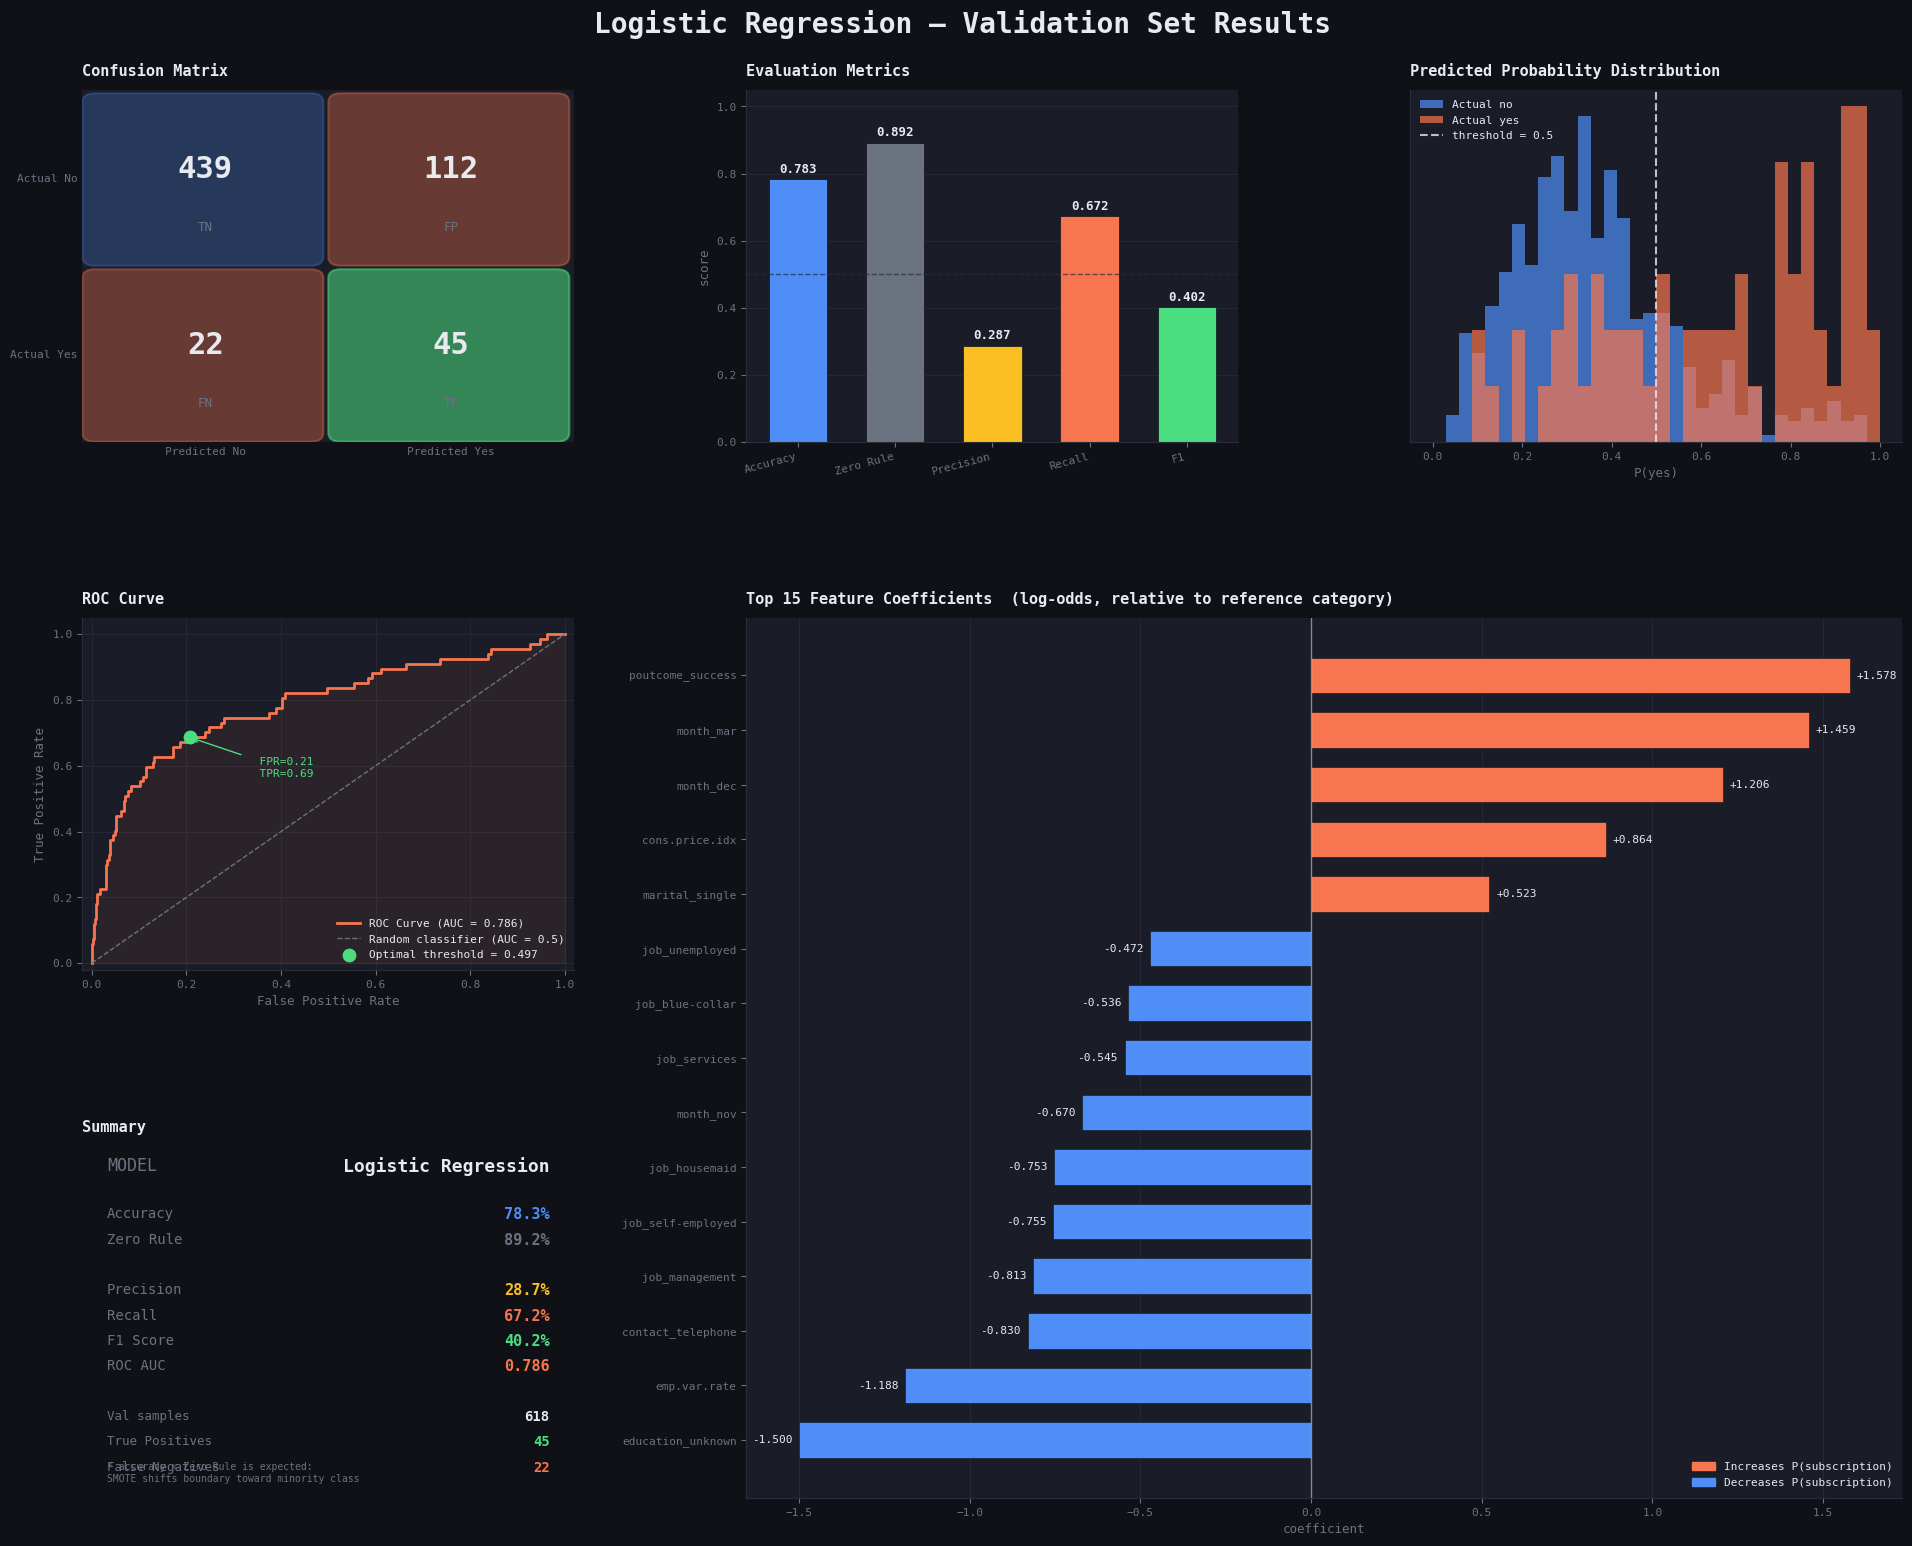

In [40]:
# ── Use actual results ────────────────────────────────────────────────────────
acc       = 0.783
prec      = 0.287
rec       = 0.672
f1        = 0.402
zero_rule = 0.892
cm        = np.array([[439, 112], [22, 45]])

# ── Palette ───────────────────────────────────────────────────────────────────
BG      = "#0f1117"; PANEL  = "#1a1d27"
ACCENT1 = "#4f8ef7"; ACCENT2 = "#f7754f"
TEXT    = "#e8eaf0"; MUTED  = "#6b7280"
GRID    = "#2a2d3a"; GREEN  = "#4ade80"; YELLOW = "#fbbf24"

plt.rcParams.update({
    "figure.facecolor": BG,   "axes.facecolor": PANEL,
    "axes.edgecolor":   GRID, "axes.labelcolor": TEXT,
    "xtick.color":      MUTED,"ytick.color":     MUTED,
    "text.color":       TEXT, "grid.color":      GRID,
    "grid.linewidth":   0.5,  "font.family":     "monospace",
})

fig = plt.figure(figsize=(20, 16), facecolor=BG)
fig.suptitle("Logistic Regression — Validation Set Results",
             fontsize=20, fontweight="bold", color=TEXT, y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.35,
                       top=0.93, bottom=0.05, left=0.06, right=0.97)

def style_ax(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, color=TEXT, fontsize=11, fontweight="bold", pad=10, loc="left")
    ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)

# ── Panel 1: Confusion Matrix ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
labels = [["TN", "FP"], ["FN", "TP"]]
colors = [[ACCENT1, ACCENT2], [ACCENT2, GREEN]]
alphas = [[0.25, 0.35], [0.35, 0.55]]
for i in range(2):
    for j in range(2):
        rect = FancyBboxPatch((j+0.05, 1-i+0.05), 0.88, 0.88,
                               boxstyle="round,pad=0.05",
                               facecolor=colors[i][j], alpha=alphas[i][j],
                               edgecolor=colors[i][j], linewidth=1.5)
        ax1.add_patch(rect)
        ax1.text(j+0.5, 1-i+0.55, str(cm[i, j]), ha="center", va="center",
                 fontsize=22, fontweight="bold", color=TEXT)
        ax1.text(j+0.5, 1-i+0.22, labels[i][j], ha="center", va="center",
                 fontsize=9, color=MUTED)
ax1.set_xlim(0, 2); ax1.set_ylim(0, 2)
ax1.set_xticks([0.5, 1.5]); ax1.set_yticks([0.5, 1.5])
ax1.set_xticklabels(["Predicted No", "Predicted Yes"], fontsize=9)
ax1.set_yticklabels(["Actual Yes", "Actual No"], fontsize=9)
style_ax(ax1, "Confusion Matrix")
ax1.spines[["left", "bottom"]].set_visible(False)
ax1.tick_params(length=0)

# ── Panel 2: Metrics bar chart ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
metrics    = {"Accuracy": acc, "Zero Rule": zero_rule,
              "Precision": prec, "Recall": rec, "F1": f1}
bar_colors = [ACCENT1, MUTED, YELLOW, ACCENT2, GREEN]
bars = ax2.bar(metrics.keys(), metrics.values(),
               color=bar_colors, edgecolor=BG, linewidth=0.5, width=0.6)
ax2.axhline(0.5, color=GRID, lw=1, ls="--", alpha=0.7)
ax2.set_ylim(0, 1.05)
for bar, val in zip(bars, metrics.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f"{val:.3f}", ha="center", fontsize=9, fontweight="bold", color=TEXT)
style_ax(ax2, "Evaluation Metrics", "", "score")
ax2.set_xticks(range(len(metrics)))
ax2.set_xticklabels(metrics.keys(), rotation=15, ha="right", fontsize=8)
ax2.yaxis.grid(True); ax2.set_axisbelow(True)

# ── Panel 3: Predicted probability distribution ───────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
bins = np.linspace(0, 1, 35)
ax3.hist(y_prob[y_val_bin==0], bins=bins, color=ACCENT1,
         alpha=0.7, density=True, label="Actual no")
ax3.hist(y_prob[y_val_bin==1], bins=bins, color=ACCENT2,
         alpha=0.7, density=True, label="Actual yes")
ax3.axvline(0.5, color=TEXT, lw=1.5, ls="--", alpha=0.8, label="threshold = 0.5")
ax3.yaxis.set_visible(False)
style_ax(ax3, "Predicted Probability Distribution", "P(yes)", "")
ax3.legend(frameon=False, fontsize=8, labelcolor=TEXT)

# ── Panel 4: ROC Curve ────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(fpr, tpr, color=ACCENT2, lw=2,
         label=f"ROC Curve (AUC = {roc_auc:.3f})")
ax4.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--",
         label="Random classifier (AUC = 0.5)")
ax4.scatter([optimal_fpr], [optimal_tpr], color=GREEN, s=80, zorder=5,
            label=f"Optimal threshold = {optimal_thr:.3f}")
ax4.annotate(f"  FPR={optimal_fpr:.2f}\n  TPR={optimal_tpr:.2f}",
             xy=(optimal_fpr, optimal_tpr),
             xytext=(optimal_fpr + 0.12, optimal_tpr - 0.12),
             color=GREEN, fontsize=8,
             arrowprops=dict(arrowstyle="->", color=GREEN, lw=1))
ax4.fill_between(fpr, tpr, alpha=0.08, color=ACCENT2)
ax4.set_xlim(-0.02, 1.02); ax4.set_ylim(-0.02, 1.05)
style_ax(ax4, "ROC Curve", "False Positive Rate", "True Positive Rate")
ax4.legend(frameon=False, fontsize=8, labelcolor=TEXT, loc="lower right")
ax4.xaxis.grid(True); ax4.yaxis.grid(True); ax4.set_axisbelow(True)

# ── Panel 5: Top 15 feature coefficients (spans rows 1-2, cols 1-2) ──────────
ax5 = fig.add_subplot(gs[1:, 1:])
coef_df = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coef":    lr.coef_[0]
}).sort_values("coef", key=abs, ascending=False).head(15).sort_values("coef")
bar_cols = [ACCENT2 if v > 0 else ACCENT1 for v in coef_df["coef"]]
bars5 = ax5.barh(coef_df["feature"], coef_df["coef"],
                  color=bar_cols, edgecolor=BG, linewidth=0.4, height=0.65)
ax5.axvline(0, color=TEXT, lw=1, alpha=0.5)
for bar, val in zip(bars5, coef_df["coef"]):
    xpos = val + 0.02 if val >= 0 else val - 0.02
    ax5.text(xpos, bar.get_y() + bar.get_height()/2,
             f"{val:+.3f}", va="center", fontsize=8, color=TEXT,
             ha="left" if val >= 0 else "right")
style_ax(ax5,
         "Top 15 Feature Coefficients  (log-odds, relative to reference category)",
         "coefficient", "")
ax5.xaxis.grid(True); ax5.set_axisbelow(True)
pos_patch = mpatches.Patch(color=ACCENT2, label="Increases P(subscription)")
neg_patch = mpatches.Patch(color=ACCENT1, label="Decreases P(subscription)")
ax5.legend(handles=[pos_patch, neg_patch], frameon=False,
           fontsize=8, labelcolor=TEXT, loc="lower right")

# ── Panel 6: Summary card ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0])
ax6.set_facecolor(PANEL)
ax6.set_xlim(0, 1); ax6.set_ylim(0, 1)
ax6.axis("off")
summary = [
    ("MODEL",           "Logistic Regression",  TEXT,    13),
    ("",                "",                     TEXT,     9),
    ("Accuracy",        f"{acc:.1%}",           ACCENT1, 11),
    ("Zero Rule",       f"{zero_rule:.1%}",     MUTED,   11),
    ("",                "",                     TEXT,     8),
    ("Precision",       f"{prec:.1%}",          YELLOW,  11),
    ("Recall",          f"{rec:.1%}",           ACCENT2, 11),
    ("F1 Score",        f"{f1:.1%}",            GREEN,   11),
    ("ROC AUC",         f"{roc_auc:.3f}",       ACCENT2, 11),
    ("",                "",                     TEXT,     9),
    ("Val samples",     "618",                  TEXT,    10),
    ("True Positives",  f"{cm[1,1]}",           GREEN,   10),
    ("False Negatives", f"{cm[1,0]}",           ACCENT2, 10),
]
y_pos = 0.97
for label, value, color, size in summary:
    if label and value:
        ax6.text(0.05, y_pos, label, color=MUTED, fontsize=size-1, va="top")
        ax6.text(0.95, y_pos, value, color=color, fontsize=size,
                 va="top", ha="right", fontweight="bold")
    y_pos -= 0.072
ax6.text(0.05, 0.04,
         "* accuracy < Zero Rule is expected:\nSMOTE shifts boundary toward minority class",
         color=MUTED, fontsize=7, va="bottom")
style_ax(ax6, "Summary")

plt.savefig("lr_results.png", dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()

# AI DISCLAIMER

AI has been used throughout the project. 

The main use has been the following:

Generating tables
Visualizing graphs
Verifying if code has run properly (and the results are what we expect)